Model Training

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [2]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X = df.drop(columns=['math score'], axis=1)

In [6]:
y = df['math score']

In [7]:
# column transformer with 3 types of transformers
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, cat_features),
        ('StandardScaler', numeric_transformer, num_features),
    ]
)

In [10]:
X = preprocessor.fit_transform(X)


In [19]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

Create an Evaluation Function to give all metrics after model Training

In [20]:
def evaluate_mode(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False)
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2_square = evaluate_mode(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2_square = evaluate_mode(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set:')
    print(f'MAE: {model_train_mae}, RMSE: {model_train_rmse}, R2 Score: {model_train_r2_square}')

    print('Model performance for Test set:')
    print(f'MAE: {model_test_mae}, RMSE: {model_test_rmse}, R2 Score: {model_test_r2_square}')
    r2_list.append(model_test_r2_square)

    print('='*67)
    print('\n')



Linear Regression
Model performance for Training set:
MAE: 4.267138671875, RMSE: 5.324354270503339, R2 Score: 0.8742556463650867
Model performance for Test set:
MAE: 4.2158203125, RMSE: 5.3959872842671395, R2 Score: 0.8803449074540941


Ridge Regression
Model performance for Training set:
MAE: 4.26498782372598, RMSE: 5.323324922741654, R2 Score: 0.8743042615212909
Model performance for Test set:
MAE: 4.211100688014261, RMSE: 5.390387016935639, R2 Score: 0.8805931485028737


Lasso Regression
Model performance for Training set:
MAE: 5.206302661246526, RMSE: 6.593815587795566, R2 Score: 0.8071462015863456
Model performance for Test set:
MAE: 5.157881810347763, RMSE: 6.519694535667419, R2 Score: 0.8253197323627853


KNN Regressor
Model performance for Training set:
MAE: 4.516749999999999, RMSE: 5.707683417990174, R2 Score: 0.8554978341651085
Model performance for Test set:
MAE: 5.621, RMSE: 7.253040741647602, R2 Score: 0.7838129945787431


Decision Tree Regressor
Model performance for Trai

In [22]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2 Score']).sort_values(by='R2 Score', ascending=False)

,Model Name,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880345
5,Random Forest Regressor,0.855267
8,CatBoostRegressor,0.851632
6,AdaBoost Regressor,0.850817
7,XGBRegressor,0.827797
2,Lasso Regression,0.825320
3,KNN Regressor,0.783813
4,Decision Tree Regressor,0.735821


In [23]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(f'Accuracy of the model is {score:.2f}%')

Accuracy of the model is 88.03%


Text(0, 0.5, 'Predicted Values')

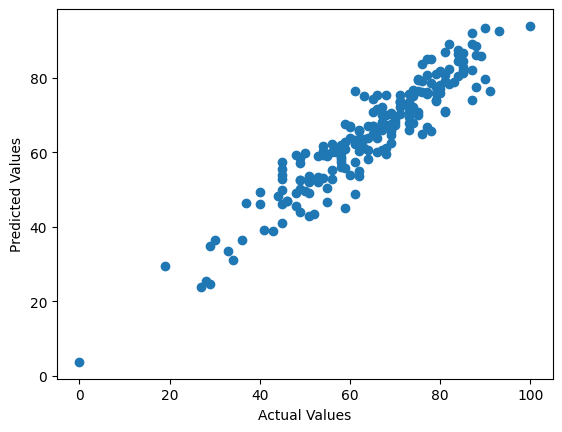

In [24]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

Difference between Actual Score and Predicted Score

In [25]:
pred_df=pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Difference': y_test-y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.507812,14.492188
737,53,58.953125,-5.953125
740,80,76.960938,3.039062
660,74,76.757812,-2.757812
411,84,87.539062,-3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,-0.031250
208,74,67.976562,6.023438
613,65,67.132812,-2.132812
